<div style="background:linear-gradient(135deg,#78350f 0%,#d97706 55%,#f59e0b 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 53 · Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Software Reliability: the Negative Binomial 🧪</div>
  <div style="font-size:15px;color:#fff7ed;max-width:740px;line-height:1.6">A test suite runs until 10 cases pass. How many total runs does that take, and how many fail along the way? Counting trials to a quota of successes is the negative binomial. We fit it and audit deployment readiness.</div>
  <div style="margin-top:16px;font-size:13px;color:#fed7aa">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup &amp; data

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
AMBER="#d97706"; TEAL="#0d9488"; INK="#1a2138"; GRID="#e6e9f2"; PINK="#db2777"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_csv("../../data/software_reliability_testing.csv")
except FileNotFoundError: df = pd.read_csv(BASE+"software_reliability_testing.csv")
print("loaded:", df.shape)
df.head()

loaded: (1000, 5)


,test_suite_id,environment,target_successes_r,failures_encountered,total_tests_run
0,TS_8000,Production_Mirror,10,4,14
1,TS_8001,UAT,10,2,12
2,TS_8002,UAT,10,1,11
3,TS_8003,Staging,10,4,14
4,TS_8004,Production_Mirror,10,1,11


<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 1 · TRIALS TO A QUOTA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The negative binomial model</div>
<div style="color:#4a5578;margin-top:6px">The geometric waits for ONE success. The negative binomial waits for r of them. Here the suite needs r=10 passes; the number of FAILURES before that is negative binomial with per-test pass probability p.</div>
</div>

In [2]:
r = int(df.target_successes_r.iloc[0])
fails = df["failures_encountered"]; total = df["total_tests_run"]
# total tests = r successes + failures; per-test pass prob p = r / mean(total)
p = r / total.mean()
print(f"target successes r   : {r}")
print(f"mean total tests run  : {total.mean():.3f}")
print(f"per-test pass prob p = r/mean(total) = {p:.4f}")
print(f"mean failures observed = {fails.mean():.3f}")
print(f"NegBinom mean failures = r(1-p)/p = {r*(1-p)/p:.3f}")

target successes r   : 10
mean total tests run  : 12.640
per-test pass prob p = r/mean(total) = 0.7911
mean failures observed = 2.640
NegBinom mean failures = r(1-p)/p = 2.640


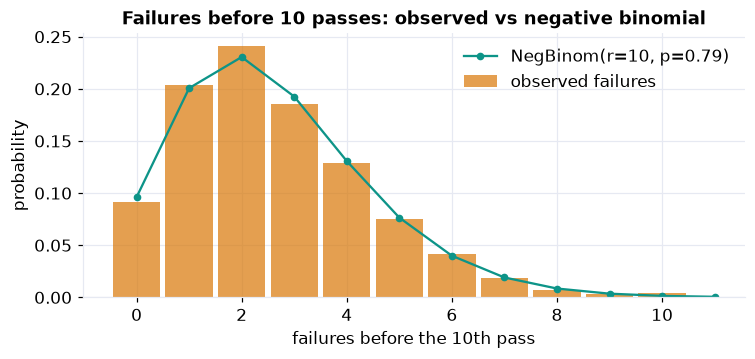

In [3]:
fig,ax=plt.subplots(figsize=(7,3.4))
kmax=int(fails.max())+1; k=np.arange(0,kmax+1)
obs=fails.value_counts(normalize=True).sort_index()
ax.bar(obs.index,obs.values,color=AMBER,alpha=0.7,width=0.9,label="observed failures")
ax.plot(k, stats.nbinom.pmf(k,r,p),"o-",color=TEAL,ms=4,label=f"NegBinom(r={r}, p={p:.2f})")
ax.set_xlabel("failures before the 10th pass"); ax.set_ylabel("probability"); ax.set_title("Failures before 10 passes: observed vs negative binomial"); ax.legend()
plt.tight_layout(); plt.show()

In [4]:
# Formal goodness-of-fit: chi-square on observed vs expected counts.
# Rule of thumb: merge adjacent bins so every EXPECTED count is at least 5, then
# chi-square = sum((obs-exp)**2 / exp), with df = (bins - 1 - number of fitted parameters).
def chisq_gof(counts, pmf, n_params):
    N = len(counts); kmax = int(counts.max())
    obs = np.array([(counts == k).sum() for k in range(kmax + 1)], float)
    exp = np.array([N * pmf(k) for k in range(kmax + 1)], float)
    obs = np.append(obs, 0.0); exp = np.append(exp, N - exp.sum())   # tail bin for k > kmax
    mo, me, co, ce = [], [], 0.0, 0.0
    for o, e in zip(obs, exp):
        co += o; ce += e
        if ce >= 5:
            mo.append(co); me.append(ce); co = ce = 0.0
    if ce > 0 and mo:
        mo[-1] += co; me[-1] += ce
    mo, me = np.array(mo), np.array(me)
    chi2 = ((mo - me) ** 2 / me).sum(); dof = len(mo) - 1 - n_params
    return chi2, dof, stats.chi2.sf(chi2, dof)

chi2, dof, pval = chisq_gof(fails.values, lambda k: stats.nbinom.pmf(k, r, p), 1)
print(f"Chi-square goodness-of-fit: chi2 = {chi2:.2f}, df = {dof}, p = {pval:.3f}  -> "
      + ("cannot reject the fit (NegativeBinomial is a good model)" if pval > 0.05 else "reject: not NegativeBinomial"))

Chi-square goodness-of-fit: chi2 = 1.77, df = 8, p = 0.987  -> cannot reject the fit (NegativeBinomial is a good model)


A **chi-square goodness-of-fit** test confirms the fit: observed failure counts versus a Negative Binomial(r, p) (rare bins merged so expected counts are at least 5) gives chi-square = 1.77 on 8 df, p = 0.99, so the Negative Binomial is a strong model for the failures-to-target-successes data.

The negative binomial PMF, C(k+r&minus;1, k) p&#7512;(1&minus;p)&#7503;, fits the observed failure counts: about **2.6 failures** before the 10th pass, at a pass rate p &#8776; 0.79. It is the geometric generalized from one success to a quota of ten.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 2 · DEPLOYMENT READINESS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">How long until the suite clears?</div>
<div style="color:#4a5578;margin-top:6px">Total tests = 10 passes + failures. Auditing readiness means asking how many total runs are needed, and the chance the suite clears within a test budget.</div>
</div>

In [5]:
print(f"mean total tests to 10 passes = r/p = {r/p:.2f}")
for budget in [12,14,16,18]:
    extra = budget - r            # failures allowed within the budget
    print(f"P(suite clears within {budget} tests) = P(failures <= {extra}) = {stats.nbinom.cdf(extra,r,p):.4f}")

mean total tests to 10 passes = r/p = 12.64
P(suite clears within 12 tests) = P(failures <= 2) = 0.5271
P(suite clears within 14 tests) = P(failures <= 4) = 0.8504
P(suite clears within 16 tests) = P(failures <= 6) = 0.9667
P(suite clears within 18 tests) = P(failures <= 8) = 0.9942


On average the suite needs about **13 total runs** to bank 10 passes. A 14-run budget clears the suite about **85%** of the time; 16 runs reach **97%** and 18 runs about **99%**. The negative binomial turns "is it ready to ship?" into a budgeted probability.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 3 · A SUM OF GEOMETRICS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Why the variance is large</div>
<div style="color:#4a5578;margin-top:6px">A negative binomial for r successes is the SUM of r independent geometric waits. We confirm by simulation, which also explains its heavy right tail.</div>
</div>

In [6]:
rng = np.random.default_rng(53)
# sum of r geometric waits (trials), minus r, = failures
geos = rng.geometric(p, size=(200_000, r)).sum(axis=1)   # total trials
sim_fail = geos - r
print(f"sum-of-geometrics: mean failures {sim_fail.mean():.3f}  (theory {r*(1-p)/p:.3f})")
print(f"scipy nbinom mean {stats.nbinom.mean(r,p):.3f}, var {stats.nbinom.var(r,p):.3f}")
print(f"a tail run: P(> 8 failures) = {stats.nbinom.sf(8,r,p):.4f}")

sum-of-geometrics: mean failures 2.639  (theory 2.640)
scipy nbinom mean 2.640, var 3.337
a tail run: P(> 8 failures) = 0.0058


Building the distribution as ten stacked geometric waits reproduces it exactly. That structure explains the shape: each pass is quick on average, but the occasional run of failures compounds, giving the negative binomial a longer right tail than a Poisson with the same mean, the reason it is the go-to model for "overdispersed" counts.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Case closed</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">Trials to a quota of r = 10 passes are negative binomial. We fit the pass rate p &#8776; 0.79, modeled the failures (mean 2.6) and total runs (mean 13), turned a test budget into a clear-probability, and rebuilt the distribution as ten stacked geometrics. The negative binomial is the geometric, scaled to a goal.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>